In [1]:
import os
import matplotlib as mpl
import pandas as pd
import requests

# Font settings
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [2]:
#let's download and import the feature table directly from the FBMN job in GNPS2
task_id = '345d29336f5a4a70b2eeaefae56f8592'
response = requests.get(f'https://gnps2.org/result?task={task_id}&viewname=quantificationdownload&resultdisplay_type=task')
directory_path = '/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/temp'

#import the metadata
metadata = pd.read_csv('/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/metadata_all_samples.txt', sep='\t') #not publicly available

with open(directory_path + task_id + '.csv', 'wb') as f:
    f.write(response.content)
    print(f"File saved at {directory_path}")
    
ftable = pd.read_csv(os.path.join(directory_path + task_id + '.csv'), sep=',')
#just keep the column relative to the samples and feature ids.
ftable = ftable[[col for col in ftable.columns if col.endswith('Peak area') or col == 'row ID']]


File saved at /Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/temp


In [3]:
#import library matches to the carnitines massQL library
library_matches = pd.read_csv('/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/library_matches_postMN_MassQL_85at5.tsv', sep='\t')

#filter first for the annotations that pass the carnitine query
library_matches = library_matches[library_matches['query_validation'] == 'carnitines']

#create another column specifically for the carnitines with putative explanation:
library_matches = library_matches[library_matches['Compound_Name'].str.contains('putative')]

library_matches['Compound_Name_simplified'] = library_matches['Compound_Name'].str.split('explanation: ').str[-1]
library_matches['Compound_Name_simplified'] = library_matches['Compound_Name_simplified'].str.replace(')', '', regex=True)
library_matches['Compound_Name_simplified'] = library_matches['Compound_Name_simplified'].str.replace(', O', ';O', regex=True)


In [4]:
# keep only matches to the carnitines with putative annotation
ftable_filtered = ftable[ftable['row ID'].isin(library_matches['#Scan#'].unique())]

#rename header to #Scan#
ftable_filtered = ftable_filtered.rename(columns={'row ID': '#Scan#'})

#merge annotation
ftable_filtered = pd.merge(ftable_filtered, library_matches[['#Scan#', 'Compound_Name_simplified']], 
                           on='#Scan#', how='left')

#create column scan_compound
ftable_filtered['scan_compound'] = ftable_filtered['#Scan#'].astype(str) + "_" + ftable_filtered['Compound_Name_simplified'].astype(str)

#put as first column
ftable_filtered = ftable_filtered[[ftable_filtered.columns[-1]] + list(ftable_filtered.columns[:-1])]

#drop Scan and compound_name_simplified columns
ftable_filtered = ftable_filtered.drop(columns=['#Scan#', 'Compound_Name_simplified'])

#transpose column
ftable_T = ftable_filtered.T
ftable_T.columns = ftable_T.iloc[0]   # take first row as header
ftable_T = ftable_T.drop(ftable_T.index[0]).reset_index()  # drop that row

#rename column and remove ' Peak area'
ftable_T = ftable_T.rename(columns={'index': 'filename'})
ftable_T['filename'] = ftable_T['filename'].str.replace(' Peak area', '', regex=True)


In [5]:
#merge with metadata
ftable_merged = pd.merge(ftable_T, metadata, on='filename', how='left')

#keep only samples
ftable_merged = ftable_merged[ftable_merged['sample_type'] == 'sample']

#concatenate tissue and time
ftable_merged['tissue_time'] = ftable_merged['tissue'] + "_" + ftable_merged['ZT'].astype(str)

#drop columns
ftable_merged = ftable_merged.drop(columns=['ZT', 'sample_type', 'tissue'])

#put as first column
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]

#use groupby to have the average of compound in each time point for each organ
ftable_merged = ftable_merged.groupby('tissue_time').median().reset_index()

#create the tissue column and time
ftable_merged['tissue'] = ftable_merged['tissue_time'].str.split('_').str[0]
ftable_merged['time'] = ftable_merged['tissue_time'].str.split('_').str[1]

#remove T from time
ftable_merged['time'] = ftable_merged['time'].str.replace('T', '', regex=True)

# Convert to ordered categorical
time_order = ['0', '4', '8', '12', '16', '20']
ftable_merged['time'] = pd.Categorical(ftable_merged['time'], categories=time_order, ordered=True)

#sort in the desired time order
ftable_merged = ftable_merged.sort_values(by=['tissue', 'time']).reset_index(drop=True)

#put as first column twice
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]

df = ftable_merged.copy()

/Users/helenarusso/opt/miniconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3331: FutureWarning: Dropping invalid columns in DataFrameGroupBy.median is deprecated. In a future version, a TypeError will be raised. Before calling .median, select only columns which should be valid for the function.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [6]:
# melt the dataframe for long format
df_melted = df.melt(
    id_vars=["tissue", "time"],     # keep these fixed
    var_name="Metabolite",          # column with metabolite names
    value_name="Abundance"          # column with abundance values
)

df_melted = df_melted[df_melted['Metabolite'] != 'tissue_time']
df_melted['Metabolite'] = df_melted['Metabolite'].str.replace(', ', ';', regex=True)

#create a column with the number of carbons of the annotation
df_melted['carbons'] = df_melted['Metabolite'].str.split('CAR ').str[-1]
df_melted['carbons'] = df_melted['carbons'].str.split(':').str[0]
df_melted['carbons'] = df_melted['carbons'].str.replace('C', '', regex=True)
df_melted['carbons'] = df_melted['carbons'].astype(int)

#column for unsaturations
df_melted['unsaturations'] = df_melted['Metabolite'].str.split('CAR ').str[-1]
df_melted['unsaturations'] = df_melted['unsaturations'].str.split(':').str[1]
df_melted['unsaturations'] = df_melted['unsaturations'].str.split(';').str[0]
df_melted['unsaturations'] = df_melted['unsaturations'].astype(int)

# column for hydroxy groups
df_melted['hydroxy'] = df_melted['Metabolite'].str.split(';O').str[-1]
df_melted.loc[df_melted["hydroxy"].str.contains("CAR", na=False), "hydroxy"] = 0
df_melted["hydroxy"] = df_melted["hydroxy"].replace("", pd.NA).fillna(1)
df_melted['hydroxy'] = df_melted['hydroxy'].astype(int)

# and include the precmz from the library searches
library_matches['Metabolite'] = library_matches['#Scan#'].astype(str) + "_" + library_matches['Compound_Name_simplified']
library_matches['Metabolite'] = library_matches['Metabolite'].str.replace(', ', ';', regex=True)


df_melted = pd.merge(df_melted, library_matches[['Metabolite', 'SpecMZ']], on='Metabolite',
                    how = 'left')

In [7]:
# and let's also create a classification for chain length and even/odd number of carbons
df_melted['carbons'] = df_melted['Metabolite'].str.split(' ').str[-1]
df_melted['carbons'] = df_melted['carbons'].str.split(':').str[0]
df_melted['carbons'] = df_melted['carbons'].str.replace('C', '', regex=True)

def classify_length(c):
    if 2 <= c <= 6:
        return "short"
    elif 7 <= c <= 12:
        return "medium"
    elif 13 <= c <= 21:
        return "long"
    elif 22 <= c <= 30:
        return "very long"
    else:
        return "unknown"

# make sure carbons is numeric
df_melted['carbons'] = df_melted['carbons'].astype(int)

df_melted['carbons_length'] = df_melted['carbons'].apply(classify_length)
df_melted['even_odd'] = df_melted['carbons'].apply(lambda x: "even" if x % 2 == 0 else "odd")

In [8]:
#then finally calculate the relative abundance per combination of tissue_compound
def calculate_relative_abundance(group):
    """
    Calculate relative abundance within each tissue-metabolite group.
    Returns None for groups where all abundances are zero.
    """
    max_abundance = group['Abundance'].max()
    if max_abundance == 0:
        return None  # This group will be dropped
    else:
        group['RelAbundance'] = (group['Abundance'] / max_abundance) * 100
        return group

# Group by tissue and metabolite, then calculate relative abundance
df_melted = df_melted.groupby(['tissue', 'Metabolite']).apply(calculate_relative_abundance).reset_index(drop=True)


# Plot

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
from scipy import ndimage
from scipy.interpolate import interp1d
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def create_ultra_smooth_tendency_lines(
    df_melted,
    variable='carbons_length',
    abundance_column='Abundance',
    show_all_points=False,
    agg_method='mean',
    color_palette='tab10',
    custom_colors=None,
    show_error_bands=True,
    output_dir='/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/figures/all_samples_blank_sub/postMN_MassQL - mz58 at 5/tendency_lines',
):
    """Create per-tissue smooth tendency lines with optional confidence bands."""
    # 1) Validate selected aggregation method.
    valid_methods = ['mean', 'median', 'sum', 'std', 'min', 'max', 'count']
    if agg_method not in valid_methods:
        raise ValueError(f"agg_method must be one of {valid_methods}")

    # 2) Keep tissues in a fixed biological order for plotting.
    tissue_order = [
        'StomachConts', 'Stomach', 'DuodenumConts', 'Duodenum',
        'JejunumConts', 'Jejunum', 'IlealCont', 'Ileum',
        'CecalConts', 'Cecum', 'ColonConts', 'Colon', 'Feces',
        'Blood', 'Urine', 'Liver', 'Kidney', 'Lung', 'Spleen', 'Heart',
        'Skin', 'Eye', 'Brain',
    ]

    available_tissues = set(df_melted['tissue'].dropna().unique())
    tissues = [tissue for tissue in tissue_order if tissue in available_tissues]
    if not tissues:
        raise ValueError('No tissues from tissue_order were found in df_melted.')

    # 3) Create one subplot per tissue.
    fig, axes = plt.subplots(len(tissues), 1, figsize=(7, 3 * len(tissues)))
    if len(tissues) == 1:
        axes = [axes]

    # Unique classes inside the selected variable (e.g., carbons_length groups).
    unique_groups = sorted(df_melted[variable].dropna().unique())

    # 4) Build default color mapping from a matplotlib palette.
    qualitative_palettes = {
        'tab10', 'tab20', 'Set1', 'Set2', 'Set3',
        'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'YlGnBl',
    }

    try:
        cmap = cm.get_cmap(color_palette)
        if color_palette in qualitative_palettes:
            colors = [cmap(i) for i in range(len(unique_groups))]
        elif len(unique_groups) <= 1:
            colors = [cmap(0.5)]
        else:
            colors = [cmap(i / (len(unique_groups) - 1)) for i in range(len(unique_groups))]
        colors_hex = [mcolors.to_hex(color) for color in colors]
    except (ValueError, KeyError):
        print(f"Warning: Color palette '{color_palette}' not found. Using 'tab10' instead.")
        cmap = cm.get_cmap('tab10')
        colors_hex = [mcolors.to_hex(cmap(i)) for i in range(len(unique_groups))]

    color_dict = dict(zip(unique_groups, colors_hex))
    # Optional manual override for specific group colors.
    if custom_colors is not None:
        color_dict.update(custom_colors)

    # 5) Loop tissue-by-tissue and draw all group lines.
    for i, tissue in enumerate(tissues):
        ax = axes[i]
        tissue_data = df_melted[df_melted['tissue'] == tissue].copy()

        # Aggregate abundance by time and selected grouping variable.
        grouped = (
            tissue_data
            .groupby(['time', variable])[abundance_column]
            .agg([agg_method, 'std', 'count'])
            .reset_index()
        )
        grouped.columns = ['time', variable, agg_method, 'std', 'count']

        for group in unique_groups:
            group_data = grouped[grouped[variable] == group].sort_values('time').copy()
            if group_data.empty:
                continue

            # Convert x/y to numeric and remove invalid values.
            x = pd.to_numeric(group_data['time'], errors='coerce').to_numpy()
            y = pd.to_numeric(group_data[agg_method], errors='coerce').to_numpy()
            valid_mask = np.isfinite(x) & np.isfinite(y)
            x = x[valid_mask]
            y = y[valid_mask]
            if len(x) < 3:
                continue

            # Compute standard error for confidence intervals when applicable.
            se = None
            if agg_method != 'std':
                std = pd.to_numeric(group_data['std'], errors='coerce').fillna(0).to_numpy()[valid_mask]
                n = pd.to_numeric(group_data['count'], errors='coerce').fillna(1).to_numpy()[valid_mask]
                if agg_method == 'sum':
                    se = np.sqrt(n) * std
                else:
                    se = std / np.sqrt(n)
                se = np.nan_to_num(se, nan=0.0)

            # Interpolate and smooth to get a visually continuous trend line.
            x_range = x.max() - x.min()
            x_interp = np.linspace(x.min() - 0.01 * x_range, x.max() + 0.01 * x_range, 500)
            x_interp[0], x_interp[-1] = x.min(), x.max()

            cubic_fit = interp1d(x, y, kind='cubic', bounds_error=False, fill_value='extrapolate')
            y_interp = cubic_fit(x_interp)

            sigma = len(x_interp) / 50
            y_smooth = ndimage.gaussian_filter1d(y_interp, sigma=sigma)

            ax.plot(x_interp, y_smooth, color=color_dict[group], linewidth=3, alpha=0.9)

            # Optional 95% confidence band around the smoothed trend.
            if show_error_bands and se is not None and len(se) > 0 and np.max(se) > 0:
                se_interp = np.interp(x_interp, x, se)
                se_smooth = ndimage.gaussian_filter1d(se_interp, sigma=sigma)
                ci_lower = y_smooth - 1.96 * se_smooth
                ci_upper = y_smooth + 1.96 * se_smooth

                if np.min(y) >= 0 and agg_method in ['mean', 'median', 'sum', 'count']:
                    ci_lower = np.maximum(ci_lower, 0)

                ax.fill_between(x_interp, ci_lower, ci_upper, color=color_dict[group], alpha=0.15)

            # Optional raw points, plus aggregated points for reference.
            if show_all_points:
                individual_data = tissue_data[tissue_data[variable] == group]
                x_ind = pd.to_numeric(individual_data['time'], errors='coerce').to_numpy()
                y_ind = pd.to_numeric(individual_data[abundance_column], errors='coerce').to_numpy()
                valid_ind = np.isfinite(x_ind) & np.isfinite(y_ind)
                ax.scatter(
                    x_ind[valid_ind], y_ind[valid_ind], color=color_dict[group],
                    s=20, alpha=0.5, zorder=4, edgecolors='black', linewidth=0.2,
                )
                ax.scatter(
                    x, y, color=color_dict[group], s=50, alpha=0.9, zorder=5,
                    edgecolors='black', linewidth=0.8, marker='D',
                )
            else:
                ax.scatter(
                    x, y, color=color_dict[group], s=30, alpha=0.9, zorder=5,
                    edgecolors='black', linewidth=0.5,
                )

        # 6) Per-axis styling and labels.
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)

        all_times = pd.to_numeric(tissue_data['time'], errors='coerce').dropna().unique()
        all_times_sorted = np.sort(all_times)
        ax.set_xticks(all_times_sorted)
        ax.set_xticklabels(all_times_sorted.astype(int))

        if i == len(tissues) - 1:
            ax.set_xlabel('Time', fontsize=12)
        else:
            ax.tick_params(axis='x', labelbottom=False, bottom=False)

        ax.set_ylabel(f"{agg_method.capitalize()} {abundance_column} ({tissue})", fontsize=11)

        # Build legend entries that match line + marker style used in the plot.
        legend_elements = [
            Line2D(
                [0], [0], color=color_dict[group], linewidth=3, marker='o', markersize=8,
                markerfacecolor=color_dict[group], markeredgecolor='white', markeredgewidth=0.5,
                label=f'{group}', alpha=0.9,
            )
            for group in unique_groups
            if group in color_dict
        ]

        ax.legend(
            handles=legend_elements,
            title=variable,
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            frameon=True,
            framealpha=0.9,
            facecolor='white',
            numpoints=1,
            handlelength=2.5,
        )

        # Force scientific notation for y-axis labels across all tissues.
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter)

    # 7) Final layout and output.
    plt.tight_layout(rect=[0, 0, 0.85, 1], pad=0.5, h_pad=-2)
    # plt.savefig(
    #     f"{output_dir}/{variable}_{agg_method}_ultra_smooth.pdf",
    #     bbox_inches='tight',
    #     dpi=300,
    # )
    plt.show()
    

In [10]:
hydroxy_colors = {
    0: '#82C180',
    1: '#FABF87', 
    2: '#E71880',
    3: '#666666'
}

carbons_length_colors = {
    'short': '#F9ED9B',
    'medium': '#9ACFB7', 
    'long': '#1F81B9',
    'very long': '#212950'
}

unsaturations_colors = {
    0: '#2078B5',
    1: '#F07E21', 
    2: '#D72829',
    3: '#8D574C',
    4: '#D37AB0',
    5: '#BDBD21', 
    6: '#2BB8CB'
}

even_odd_colors = {
    'even': '#8C389B',
    'odd':  '#E28DB9'
}

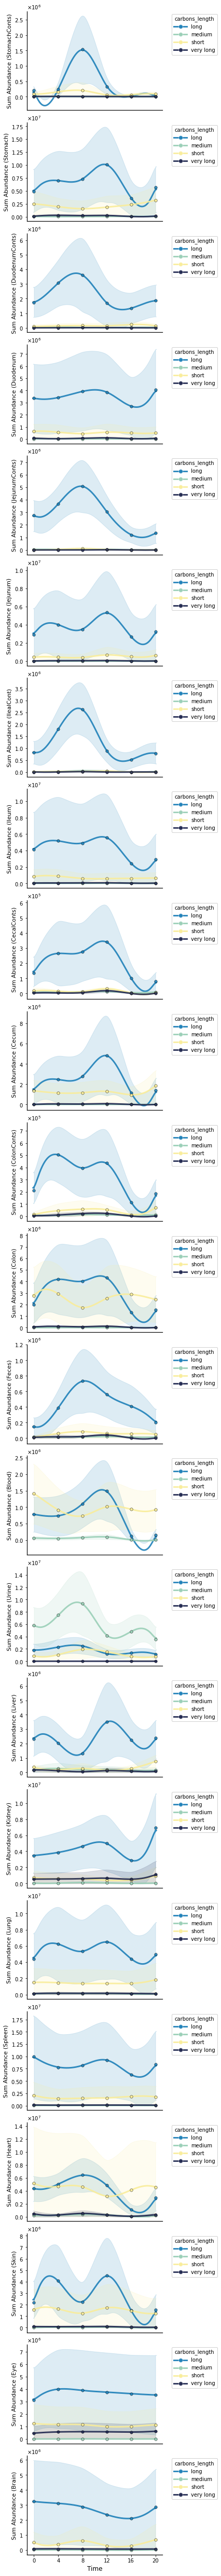

In [11]:
create_ultra_smooth_tendency_lines(df_melted, variable='carbons_length', agg_method='sum', 
                                   abundance_column='Abundance', show_all_points=False,
                                   custom_colors=carbons_length_colors, show_error_bands=True)


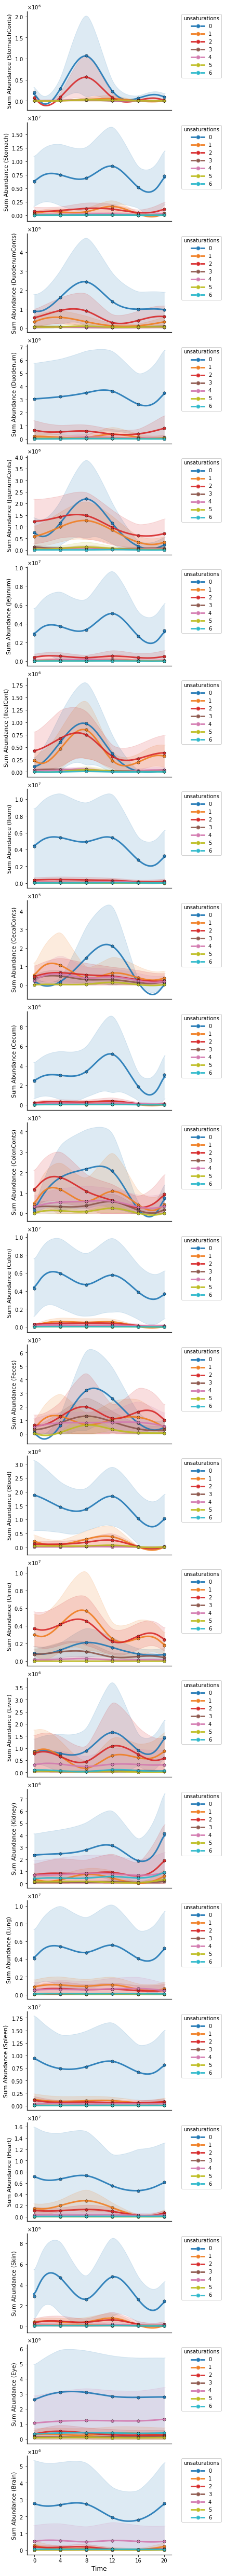

In [13]:
create_ultra_smooth_tendency_lines(df_melted, variable='unsaturations', agg_method='sum', 
                                   abundance_column='Abundance', show_all_points=False,
                                   custom_colors=unsaturations_colors, show_error_bands=True)


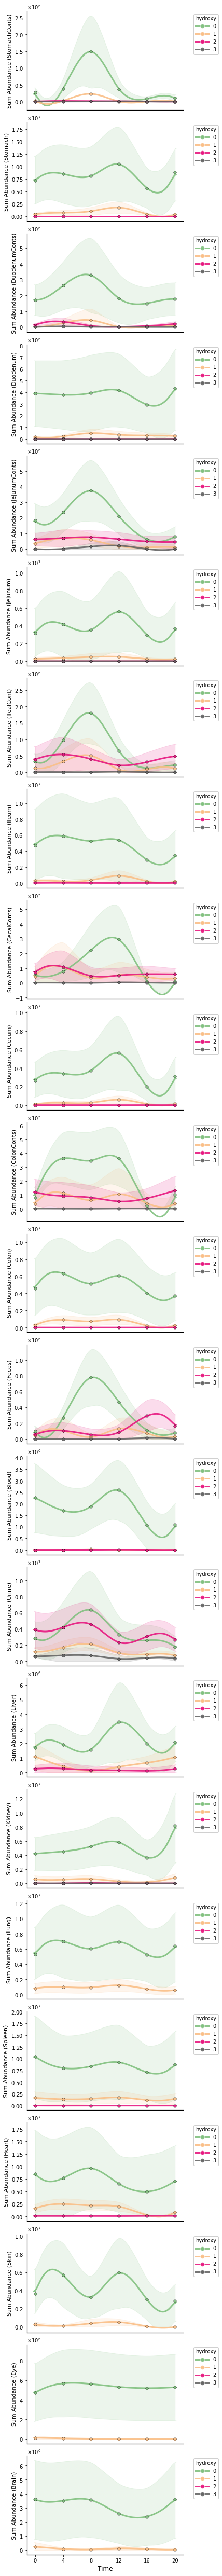

In [14]:
create_ultra_smooth_tendency_lines(df_melted, variable='hydroxy', agg_method='sum', 
                                   abundance_column='Abundance', show_all_points=False,
                                   custom_colors=hydroxy_colors, show_error_bands=True)


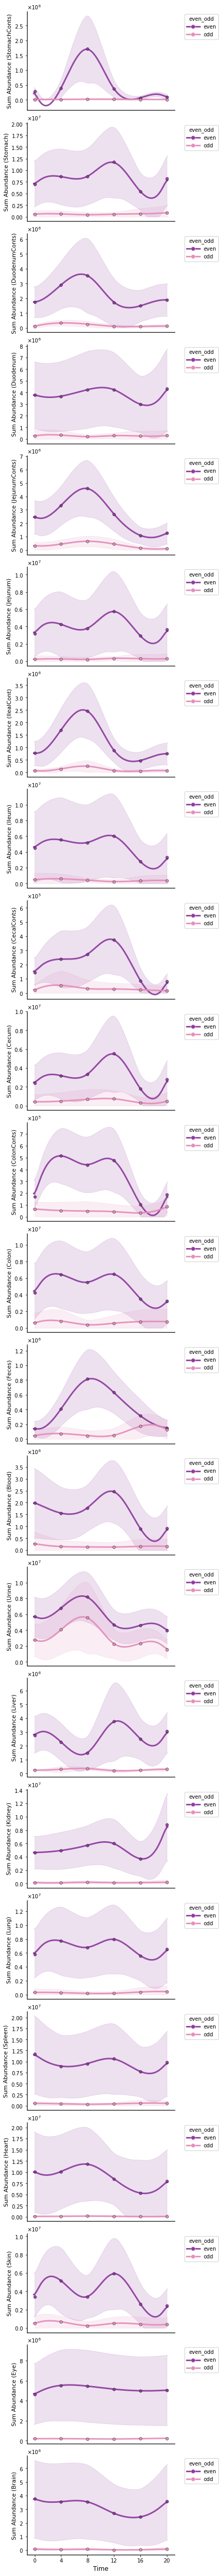

In [15]:
create_ultra_smooth_tendency_lines(df_melted, variable='even_odd', agg_method='sum', 
                                   abundance_column='Abundance', show_all_points=False,
                                   custom_colors=even_odd_colors, show_error_bands=True)
